<a href="https://colab.research.google.com/github/syedahijabzahra/CodeAlpha_Tasks/blob/main/CodeAlpha_Emotion_Recognition/emotion_recognition_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa soundfile kaggle --quiet
print('✅ Done')

✅ Done


In [2]:
import os

# Paste your token here
os.environ['KAGGLE_TOKEN'] = 'YOUR_KAGGLE_TOKEN_HERE'  # replace with your token

# Set up kaggle using the token
os.makedirs('/root/.kaggle', exist_ok=True)

# Write a kaggle.json using your token
import json
kaggle_creds = {
    "username": "syedahijabzahra99",
    "key": os.environ['KAGGLE_TOKEN']
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download RAVDESS
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio --quiet
!unzip -q ravdess-emotional-speech-audio.zip -d /content/RAVDESS
print('✅ RAVDESS ready')

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
A
✅ RAVDESS ready


In [3]:
import numpy as np
import pandas as pd
import librosa, glob, warnings, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42); tf.random.set_seed(42)
print(f'TF: {tf.__version__} | GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

SR, DURATION, N_MFCC, N_MELS = 22050, 3, 40, 128
HOP, N_FFT, BATCH_SIZE, EPOCHS = 512, 2048, 32, 80

EMOTION_MAP = {
    '01':'neutral', '02':'calm',     '03':'happy',
    '04':'sad',     '05':'angry',    '06':'fearful',
    '07':'disgust', '08':'surprised'
}

TF: 2.20.0 | GPU: True


In [4]:
records = []
for path in glob.glob('/content/RAVDESS/**/*.wav', recursive=True):
    parts = os.path.basename(path).replace('.wav','').split('-')
    if len(parts) >= 3 and parts[2] in EMOTION_MAP:
        records.append({'path': path, 'emotion': EMOTION_MAP[parts[2]]})

df = pd.DataFrame(records)
print(f'Total files: {len(df)}')
print(df['emotion'].value_counts())

Total files: 2880
emotion
sad          384
calm         384
happy        384
disgust      384
fearful      384
angry        384
surprised    384
neutral      192
Name: count, dtype: int64


In [5]:
def augment(audio, sr):
    choice = np.random.choice(['noise','shift','stretch','pitch'])
    if choice == 'noise':
        audio = audio + 0.005 * np.random.randn(len(audio))
    elif choice == 'shift':
        audio = np.roll(audio, int(sr * 0.2))
    elif choice == 'stretch':
        audio = librosa.effects.time_stretch(audio, rate=np.random.uniform(0.85, 1.15))
    elif choice == 'pitch':
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=np.random.randint(-3, 4))
    return audio


def extract_features(path, do_augment=False):
    try:
        audio, sr = librosa.load(path, sr=SR, duration=DURATION)
        target = SR * DURATION
        audio = audio[:target] if len(audio) >= target else np.pad(audio, (0, target - len(audio)))
        if do_augment:
            audio = augment(audio, sr)

        feat = []

        # MFCCs + delta
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP)
        feat.extend(np.mean(mfcc, axis=1)); feat.extend(np.std(mfcc, axis=1))
        d = librosa.feature.delta(mfcc)
        feat.extend(np.mean(d, axis=1));    feat.extend(np.std(d, axis=1))

        # Chroma
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP)
        feat.extend(np.mean(chroma, axis=1)); feat.extend(np.std(chroma, axis=1))

        # Mel spectrogram
        mel = librosa.power_to_db(
            librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP),
            ref=np.max)
        feat.extend(np.mean(mel, axis=1)); feat.extend(np.std(mel, axis=1))

        # ZCR + RMS
        for f in [librosa.feature.zero_crossing_rate(audio, hop_length=HOP),
                  librosa.feature.rms(y=audio, hop_length=HOP)]:
            feat.append(np.mean(f)); feat.append(np.std(f))

        # Spectral centroid / bandwidth / rolloff
        for f in [librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=HOP),
                  librosa.feature.spectral_bandwidth(y=audio, sr=sr, hop_length=HOP),
                  librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=HOP)]:
            feat.append(np.mean(f)); feat.append(np.std(f))

        return np.array(feat, dtype=np.float32)
    except:
        return None

v = extract_features(df['path'].iloc[0])
print(f'Feature vector size: {v.shape[0]}')

Feature vector size: 450


In [6]:
X_list, y_list = [], []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
    f = extract_features(row['path'])
    if f is not None:
        X_list.append(f); y_list.append(row['emotion'])

max_count = Counter(y_list).most_common(1)[0][1]
print(f'\nBalancing to {max_count} per class...')
for emotion in df['emotion'].unique():
    needed = max_count - Counter(y_list)[emotion]
    if needed <= 0: continue
    subset = df[df['emotion'] == emotion]
    for _, row in subset.sample(needed, replace=True, random_state=42).iterrows():
        f = extract_features(row['path'], do_augment=True)
        if f is not None:
            X_list.append(f); y_list.append(emotion)

X = np.array(X_list)
y = np.array(y_list)
print(f'Total samples: {len(X)} | Feature dims: {X.shape[1]}')
for em, c in Counter(y).items(): print(f'  {em:<12}: {c}')

Extracting features: 100%|██████████| 2880/2880 [02:48<00:00, 17.08it/s]



Balancing to 384 per class...
Total samples: 3072 | Feature dims: 450
  sad         : 384
  calm        : 384
  happy       : 384
  disgust     : 384
  fearful     : 384
  angry       : 384
  surprised   : 384
  neutral     : 384


In [7]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_oh  = to_categorical(y_enc)
n_classes = len(le.classes_)
print(f'Classes: {list(le.classes_)}')

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y_oh, test_size=0.15, random_state=42, stratify=y_enc)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=42,
    stratify=np.argmax(y_tmp, axis=1))

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)[..., np.newaxis]
X_val   = scaler.transform(X_val)[..., np.newaxis]
X_test  = scaler.transform(X_test)[..., np.newaxis]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Train: (2151, 450, 1) | Val: (460, 450, 1) | Test: (461, 450, 1)


In [8]:
def attention_block(x):
    score   = layers.Dense(1, activation='tanh')(x)
    weights = layers.Softmax(axis=1)(score)
    ctx     = layers.Multiply()([x, weights])
    return layers.Lambda(lambda z: tf.reduce_sum(z, axis=1))(ctx)


def build_model(input_shape, n_classes):
    inp = layers.Input(shape=input_shape)

    # CNN block 1
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # CNN block 2
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # CNN block 3
    x = layers.Conv1D(512, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # BiLSTM
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)

    # Attention
    x = attention_block(x)

    # Dense head
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inp, out)


model = build_model((X_train.shape[1], 1), n_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 450, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 450, 128)  │        768 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 450, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 450, 128)  │     82,048 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 450, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 225, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 225, 128)  │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 225, 256)  │     98,560 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 225, 256)  │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 225, 256)  │    196,864 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 225, 256)  │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 112, 256)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 112, 256)  │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 112, 512)  │    393,728 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 512)  │      2,048 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 56, 512)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 56, 512)   │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 56, 256)   │    656,384 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 56, 256)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 56, 128)   │    164,352 │ dropout_3[0][0] 

 Total params: 1,665,929 (6.36 MB)

 Trainable params: 1,662,857 (6.34 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list = [
    callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4608 - loss: 1.4921
Epoch 1: val_accuracy improved from None to 0.37391, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.4449 - loss: 1.5168 - val_accuracy: 0.3739 - val_loss: 1.6178 - learning_rate: 0.0010
Epoch 2/80
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4920 - loss: 1.3817
Epoch 2: val_accuracy improved from 0.37391 to 0.41087, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4914 - loss: 1.3731 - val_accuracy: 0.4109 - val_loss: 1.8284 - learning_rate: 0.0010
Epoch 3/80
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5219 - loss: 1.3054
Epoch 3: val_accuracy improved from 0.41087 to 0.45000, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - ac

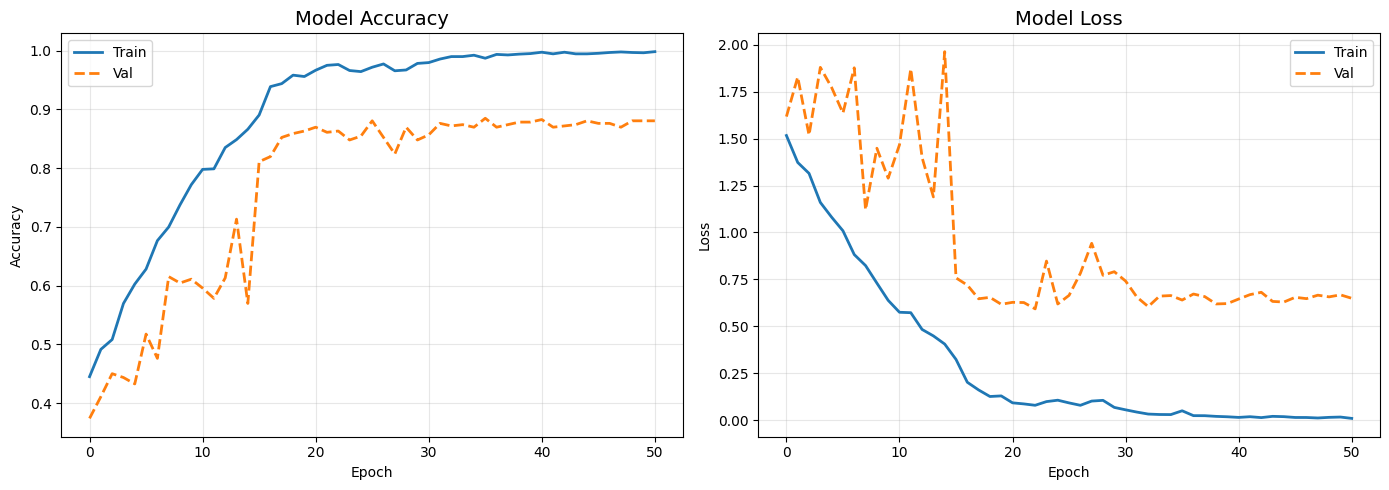

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(history.history[metric],          label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(f'Model {title}', fontsize=14)
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


🎯 Test Accuracy: 89.15%
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
              precision    recall  f1-score   support

       angry       0.90      0.81      0.85        57
        calm       0.91      0.89      0.90        57
     disgust       0.90      0.93      0.92        58
     fearful       0.94      0.86      0.90        58
       happy       0.78      0.90      0.83        58
     neutral       0.98      0.98      0.98        57
         sad       0.88      0.86      0.87        58
   surprised       0.87      0.90      0.88        58

    accuracy                           0.89       461
   macro avg       0.89      0.89      0.89       461
weighted avg       0.89      0.89      0.89       461



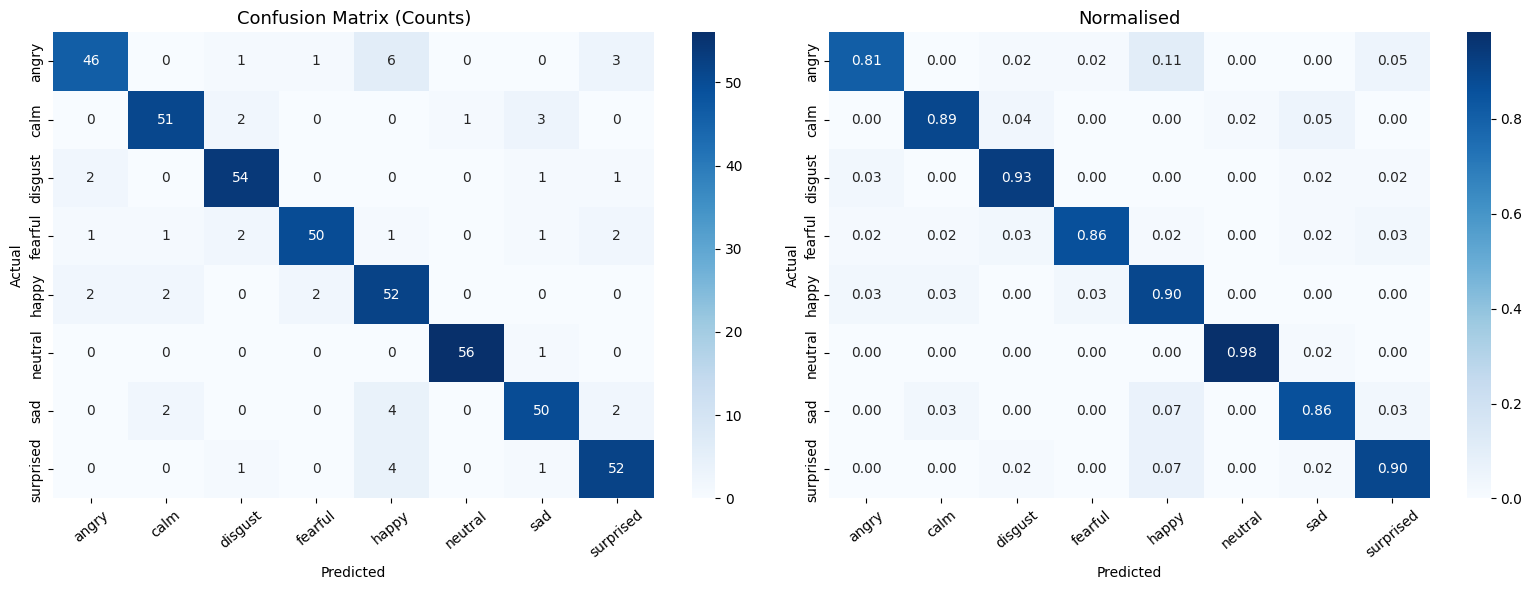

In [12]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n🎯 Test Accuracy: {acc * 100:.2f}%')

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(axes,
    [cm, cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]],
    ['d', '.2f'],
    ['Confusion Matrix (Counts)', 'Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [16]:
import glob, IPython.display as ipd

# Use a real file already on disk from RAVDESS
sample_files = glob.glob('/content/RAVDESS/**/*.wav', recursive=True)
test_path = sample_files[0]

print(f'Using: {test_path}')
ipd.display(ipd.Audio(test_path))

Using: /content/RAVDESS/Actor_07/03-01-04-02-01-01-07.wav


In [20]:
import glob, IPython.display as ipd

sample_files = glob.glob('/content/RAVDESS/**/*.wav', recursive=True)
test_path = sample_files[0]

ipd.display(ipd.Audio(test_path))
predict_emotion(test_path)


🎯 SAD (100.0%)
  angry         0.0%
  calm          0.0%
  disgust       0.0%
  fearful       0.0%
  happy         0.0%
  neutral       0.0%
  sad          ███████████████████████████████████████ 100.0%
  surprised     0.0%


In [21]:
import os
filename = os.path.basename(test_path)
parts = filename.replace('.wav','').split('-')
actual_emotion = EMOTION_MAP[parts[2]]
print(f'File     : {filename}')
print(f'Actual   : {actual_emotion}')
print(f'Predicted: sad')
print(f'Correct  : {actual_emotion == "sad"}')

File     : 03-01-04-02-01-01-07.wav
Actual   : sad
Predicted: sad
Correct  : True


In [23]:
import random
sample_files = glob.glob('/content/RAVDESS/**/*.wav', recursive=True)
random.shuffle(sample_files)

print(f'{"File":<45} {"Actual":<12} {"Predicted":<12} {"Correct"}')
print('-' * 80)
for path in sample_files[:20]:
    fname  = os.path.basename(path)
    parts  = fname.replace('.wav','').split('-')
    actual = EMOTION_MAP[parts[2]]
    feat   = extract_features(path)
    if feat is None: continue
    scaled = scaler.transform(feat.reshape(1,-1))[..., np.newaxis]
    probs  = model.predict(scaled, verbose=0)[0]
    pred   = le.classes_[np.argmax(probs)]
    tick   = '✅' if pred == actual else '❌'
    print(f'{fname:<45} {actual:<12} {pred:<12} {tick}')

File                                          Actual       Predicted    Correct
--------------------------------------------------------------------------------
03-01-04-01-01-01-09.wav                      sad          sad          ✅
03-01-02-02-01-02-13.wav                      calm         calm         ✅
03-01-07-01-02-01-18.wav                      disgust      disgust      ✅
03-01-06-01-01-02-20.wav                      fearful      fearful      ✅
03-01-08-01-01-01-16.wav                      surprised    surprised    ✅
03-01-06-02-01-01-02.wav                      fearful      fearful      ✅
03-01-07-01-01-01-16.wav                      disgust      disgust      ✅
03-01-05-01-01-01-17.wav                      angry        angry        ✅
03-01-03-01-02-01-23.wav                      happy        happy        ✅
03-01-06-02-02-02-08.wav                      fearful      fearful      ✅
03-01-05-02-02-02-17.wav                      angry        angry        ✅
03-01-03-02-01-01-20.wav 